In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
import plotly.express as px

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',500)

def switch_plot_mode(mode):
    if mode == 'dark':
        plt.style.use('dark_background')
        plt.rcParams['figure.figsize'] = (12,6)
        plt.rcParams['font.size'] = 12
        plt.rcParams['text.color'] = 'white'
        plt.rcParams['axes.labelcolor'] = 'white'
        plt.rcParams['xtick.color'] = 'white'
        plt.rcParams['ytick.color'] = 'white'
    elif mode == 'light':
        plt.style.use('default')
        plt.rcParams['figure.figsize'] = (12,6)
        plt.rcParams['font.size'] = 12
        plt.rcParams['text.color'] = 'black'
        plt.rcParams['axes.labelcolor'] = 'black'
        plt.rcParams['xtick.color'] = 'black'
        plt.rcParams['ytick.color'] = 'black'

switch_plot_mode('light')
        


In [58]:
data = pd.read_csv("superstore_dataset.csv")
data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,12/06/16,16/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10009,1048,CA-2016-169103,08/03/16,13/03/16,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,United States,Miami,Florida,33142,South,FUR-FU-10004006,Furniture,Furnishings,"Deflect-o DuraMat Lighweight, Studded, Beveled...",102.3600,3.0,0.20,-3.8385
10010,9613,CA-2016-110086,18/09/16,22/09/16,Standard Class,BD-11320,Bill Donatelli,Consumer,United States,Woodland,California,95695,West,TEC-PH-10001299,Technology,Phones,Polycom CX300 Desktop Phone USB VoIP phone,239.9840,2.0,0.20,23.9984
10011,9614,CA-2014-128524,11/11/14,2014-11-13,First Class,MZ-17515,Mary Zewe,Corporate,United States,Seattle,Washington,98115,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,22.9800,1.0,0.00,6.8940
10012,9615,CA-2014-128524,11/11/14,2014-11-13,First Class,MZ-17515,Mary Zewe,Corporate,United States,Seattle,Washington,98115,West,TEC-AC-10002718,Technology,Accessories,Belkin Standard 104 key USB Keyboard,102.1300,7.0,0.00,15.3195


In [59]:
# Exploratory Data Analysis (EDA) step - Data Cleaning


In [60]:
data.head(5)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,08/11/16,11/11/16,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,12/06/16,16/06/16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,11/10/15,18/10/15,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [61]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10014 entries, 0 to 10013
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10014 non-null  int64  
 1   Order ID       10014 non-null  object 
 2   Order Date     10014 non-null  object 
 3   Ship Date      10014 non-null  object 
 4   Ship Mode      9916 non-null   object 
 5   Customer ID    10014 non-null  object 
 6   Customer Name  10014 non-null  object 
 7   Segment        10014 non-null  object 
 8   Country        10014 non-null  object 
 9   City           10014 non-null  object 
 10  State          10014 non-null  object 
 11  Postal Code    10014 non-null  int64  
 12  Region         10014 non-null  object 
 13  Product ID     10014 non-null  object 
 14  Category       10014 non-null  object 
 15  Sub-Category   10014 non-null  object 
 16  Product Name   10014 non-null  object 
 17  Sales Price    10014 non-null  float64
 18  Quanti

In [62]:
data.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode        98
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales Price       0
Quantity         18
Discount          0
Profit            0
dtype: int64

In [63]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales Price', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [64]:
data.shape

(10014, 21)

In [65]:
data.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales Price      float64
Quantity         float64
Discount         float64
Profit           float64
dtype: object

In [66]:
data.describe()

,Row ID,Postal Code,Sales Price,Quantity,Discount,Profit
count,10014.000000,10014.000000,10014.000000,9996.000000,10014.000000,10014.000000
mean,4997.523367,55205.131616,230.038424,3.792517,0.156240,28.708317
std,2888.981754,32066.711027,623.057359,2.231021,0.206392,234.154272
min,1.000000,1040.000000,-31.500000,1.000000,0.000000,-6599.978000
25%,2494.250000,23223.000000,17.280000,2.000000,0.000000,1.731375
50%,4997.500000,57103.000000,54.780000,3.000000,0.200000,8.666500
75%,7500.750000,90008.000000,209.970000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [67]:
data.nunique()


Row ID           9994
Order ID         5009
Order Date       1240
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              54
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales Price      5829
Quantity           14
Discount           12
Profit           7287
dtype: int64

Handling Duplicates

In [68]:
duplicate_rows_mask = data.duplicated()
dups = data.loc[duplicate_rows_mask]

print(f"Total number of rows: {data.shape[0]}")
print(f"Number of duplicate rows found: {len(dups)}")

Total number of rows: 10014
Number of duplicate rows found: 17


In [69]:
duplicate_rowid_mask = data.duplicated(["Row ID"])
print(f"Number of duplicate (entire) rows are - {len(data.loc[duplicate_rows_mask])}")
print(f"Number of rows with duplicate Row ID attribute are - {len(data.loc[duplicate_rowid_mask])}")

Number of duplicate (entire) rows are - 17
Number of rows with duplicate Row ID attribute are - 20


In [70]:
data.loc[duplicate_rowid_mask & -duplicate_rows_mask]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
9998,20,CA-2014-143336,27/08/14,2014-9-1,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,California,94109,West,TEC-PH-10001949,Technology,Phones,Cisco SPA 501G IP Phone,213.480,3.0,0.2,16.0110
10000,8852,CA-2015-140718,02/07/15,04/07/15,First Class,FA-14230,Frank Atkinson,Corporate,United States,Raleigh,North Carolina,27604,South,OFF-PA-10002250,Office Supplies,Paper,Things To Do Today Pad,-9.392,2.0,0.2,3.2872
10005,1044,CA-2017-115651,09/07/17,12/07/17,First Class,NS-18640,Noel Staavos,Corporate,United States,Chicago,Illinois,60610,Central,OFF-AR-10001130,Office Supplies,Art,"Quartet Alpha White Chalk, 12/Pack",-8.840,5.0,0.2,2.9835


In [71]:
duplicate_rows_mask2 = data.duplicated(keep = "last")
duplicate_rowid_mask2 = data.duplicated(["Row ID"],keep = "last")
data.loc[duplicate_rowid_mask2 & -duplicate_rows_mask2]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
19,20,CA-2014-143336,27/08/14,2014-9-1,Second Class,ZD-21925,Zuschuss Donatelli,Consumer,United States,San Francisco,California,94109,West,TEC-PH-10001949,Technology,Phones,Cisco SPA 501G IP Phone,213.480,NaN,0.2,16.0110
1043,1044,CA-2017-115651,09/07/17,12/07/17,First Class,NS-18640,Noel Staavos,Corporate,United States,Chicago,Illinois,60610,Central,OFF-AR-10001130,Office Supplies,Art,"Quartet Alpha White Chalk, 12/Pack",8.840,5.0,0.2,2.9835
8851,8852,CA-2015-140718,02/07/15,04/07/15,First Class,FA-14230,Frank Atkinson,Corporate,United States,Raleigh,North Carolina,27604,South,OFF-PA-10002250,Office Supplies,Paper,Things To Do Today Pad,9.392,2.0,0.2,3.2872


In [72]:
neg_sales_prices = data.loc[data['Sales Price']<0]
neg_sales_prices

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
9794,9795,CA-2014-127166,21/05/14,2014-5-23,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,TX,77070,Central,OFF-BI-10000977,Office Supplies,Binders,Ibico Plastic Spiral Binding Combs,-18.240,3.0,0.8,-31.0080
9984,9985,CA-2015-100251,17/05/15,23/05/15,Standard Class,DV-13465,Dianna Vittorini,Consumer,United States,Long Beach,NY,11561,East,OFF-LA-10003766,Office Supplies,Labels,Self-Adhesive Removable Labels,-31.500,10.0,0.0,15.1200
10000,8852,CA-2015-140718,02/07/15,04/07/15,First Class,FA-14230,Frank Atkinson,Corporate,United States,Raleigh,North Carolina,27604,South,OFF-PA-10002250,Office Supplies,Paper,Things To Do Today Pad,-9.392,2.0,0.2,3.2872
10005,1044,CA-2017-115651,09/07/17,12/07/17,First Class,NS-18640,Noel Staavos,Corporate,United States,Chicago,Illinois,60610,Central,OFF-AR-10001130,Office Supplies,Art,"Quartet Alpha White Chalk, 12/Pack",-8.840,5.0,0.2,2.9835


In [73]:
data['Sales Price'] = np.abs(data['Sales Price'])
neg_sales_prices = data.loc[data['Sales Price']<0]
neg_sales_prices

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit


In [74]:
labels_to_drop = list(data.loc[duplicate_rowid_mask2].index)
data.drop(labels_to_drop, axis="index", inplace = True)
data.shape

(9994, 21)

> Dropping the Row Id column as its need is sufficed
> The dataframe index maintains a unique row number for each row same as row_id column

In [75]:
data.drop(["Row ID"], axis = 'columns', inplace = True)

In [76]:
# Do duplicate rows still exist?
duplicate_rows_mask = data.duplicated()
data[duplicate_rows_mask]

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
3406,US-2014-150119,23/04/14,2014-4-27,Standard Class,LB-16795,Laurel Beltran,Home Office,United States,Columbus,Ohio,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2.0,0.3,-12.0588


In [77]:
data.drop(data[duplicate_rows_mask].index, axis="index", inplace = True)
data.shape

(9993, 20)

In [78]:
data.reset_index(drop=True, inplace=True)

Handling Duplicates : Summary
findings:
 1. A total of 21 duplicate rows were identified and removed from the dataset.
 2. The total number of rows in the DataFrame was reduced from 10,014 to 9,993.
 3. Since the index would certain missing values, we reset the index again.

In [79]:
# Data Handling

In [80]:
data['Order Date'].unique()[0:100]

array(['08/11/16', '12/06/16', '11/10/15', '09/06/14', '15/04/17',
       '05/12/16', '22/11/15', '11/11/14', '09/12/16', '16/07/17',
       '25/09/15', '16/01/16', '17/09/15', '19/10/17', '08/12/16',
       '27/12/15', '10/09/17', '17/07/16', '19/09/17', '11/03/16',
       '20/10/14', '20/06/16', '18/04/15', '11/12/16', '17/06/16',
       '24/11/17', '30/04/15', '05/12/14', '04/06/16', '18/09/16',
       '14/09/17', '26/04/15', '09/12/17', '26/11/14', '12/10/14',
       '03/09/15', '13/11/17', '28/05/17', '26/10/17', '05/04/16',
       '17/09/16', '31/01/15', '06/11/17', '09/11/17', '17/06/17',
       '06/09/16', '29/08/16', '01/12/16', '13/11/15', '23/11/17',
       '15/10/15', '25/12/17', '03/11/16', '25/08/14', '02/03/15',
       '05/04/15', '26/12/14', '20/09/14', '05/11/17', '06/11/16',
       '02/02/17', '13/10/16', '05/09/16', '18/09/17', '22/12/17',
       '07/09/15', '22/10/14', '13/03/16', '31/05/15', '28/05/15',
       '01/03/14', '20/11/16', '11/05/16', '28/12/15', '16/11/

In [81]:
data['Order Date'] = pd.to_datetime(data['Order Date'], format = '%d/%m/%y')
data.dtypes

Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales Price             float64
Quantity                float64
Discount                float64
Profit                  float64
dtype: object

Therefore, all 9,993 Order Date got changed to Date Time

In [82]:
data['Ship Date'].unique()[0:100]

array(['11/11/16', '16/06/16', '18/10/15', '2014-6-14', '20/04/17',
       '10/12/16', '26/11/15', '2014-11-18', '13/12/16', '18/07/17',
       '30/09/15', '20/01/16', '21/09/15', '23/10/17', '31/12/15',
       '15/09/17', '22/07/16', '23/09/17', '13/03/16', '2014-10-25',
       '25/06/16', '22/04/15', '17/12/16', '18/06/16', '30/11/15',
       '05/05/15', '2014-12-10', '06/06/16', '23/09/16', '17/09/17',
       '02/05/15', '11/12/17', '2014-12-1', '15/06/16', '2014-10-16',
       '08/09/15', '16/11/17', '30/05/17', '02/11/17', '10/04/16',
       '22/09/16', '05/02/15', '12/11/17', '11/11/17', '20/06/17',
       '11/09/16', '02/09/16', '04/12/16', '17/11/15', '28/11/17',
       '20/10/15', '30/12/17', '10/11/16', '2014-8-27', '06/03/15',
       '10/04/15', '2014-12-28', '2014-9-25', '05/02/17', '19/10/16',
       '07/09/16', '27/12/17', '12/09/15', '2014-10-28', '09/12/16',
       '16/03/16', '02/06/15', '03/06/15', '2014-3-6', '24/11/16',
       '12/05/16', '20/11/16', '2014-9-12', '2

In [83]:
# Handling ship dates of type - dd/mm/yy
dt_type1_mask = data['Ship Date'].str.contains(r'\d{2}[/]\d{2}[/]\d{2}', regex = True, na=False)
data.loc[dt_type1_mask, 'Ship Date']

0       11/11/16
1       11/11/16
2       16/06/16
3       18/10/15
4       18/10/15
          ...   
9985    12/07/17
9986    16/10/17
9987    13/03/16
9988    13/03/16
9989    22/09/16
Name: Ship Date, Length: 8054, dtype: object

In [84]:
data.loc[dt_type1_mask, 'Ship Date'] = pd.to_datetime(data.loc[dt_type1_mask, 'Ship Date'], format = '%d/%m/%y' )
data.loc[dt_type1_mask, 'Ship Date']

0       2016-11-11 00:00:00
1       2016-11-11 00:00:00
2       2016-06-16 00:00:00
3       2015-10-18 00:00:00
4       2015-10-18 00:00:00
               ...         
9985    2017-07-12 00:00:00
9986    2017-10-16 00:00:00
9987    2016-03-13 00:00:00
9988    2016-03-13 00:00:00
9989    2016-09-22 00:00:00
Name: Ship Date, Length: 8054, dtype: object

In [85]:
data = data.astype({'Ship Date': 'datetime64[ns]'})
data.dtypes

Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales Price             float64
Quantity                float64
Discount                float64
Profit                  float64
dtype: object

Check Whether or not the years in Order Date and Order Id match

In [86]:
# Order Id : xx-YYY-xxxxx
order_id_yrs = data['Order ID'].str.extract(r'-(\d{2,4})-', expand = False).astype('int')
order_date_yrs = data['Order Date'].dt.year

inconsistent_order_dates_mask = (order_id_yrs != order_date_yrs)

inconsistent_order_dates = data[inconsistent_order_dates_mask]
print(f'# records with inconsistent order dates are - {inconsistent_order_dates.shape[0]}')

# records with inconsistent order dates are - 40


In [87]:
inconsistent_order_dates

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit
58,CA-2015-135545,2017-11-24,2015-11-30,Standard Class,KM-16720,Kunst Miller,Consumer,United States,Los Angeles,California,90004,West,TEC-AC-10004633,Technology,Accessories,Verbatim 25 GB 6x Blu-ray Single Layer Recorda...,13.980,2.0,0.0,6.1512
59,CA-2015-135545,2017-11-24,2015-11-30,Standard Class,KM-16720,Kunst Miller,Consumer,United States,Los Angeles,California,90004,West,OFF-BI-10001078,Office Supplies,Binders,"Acco PRESSTEX Data Binder with Storage Hooks, ...",25.824,6.0,0.2,9.3612
60,CA-2015-135545,2017-11-24,2015-11-30,Standard Class,KM-16720,Kunst Miller,Consumer,United States,Los Angeles,California,90004,West,OFF-PA-10003892,Office Supplies,Paper,Xerox 1943,146.730,3.0,0.0,68.9631
61,CA-2015-135545,2017-11-24,2015-11-30,Standard Class,KM-16720,Kunst Miller,Consumer,United States,Los Angeles,California,90004,West,FUR-FU-10000397,Furniture,Furnishings,Luxo Economy Swing Arm Lamp,79.760,4.0,0.0,22.3328
939,CA-2015-120880,2013-05-29,2015-06-03,Standard Class,JL-15850,John Lucas,Consumer,United States,Seattle,Washington,98105,West,OFF-PA-10004101,Office Supplies,Paper,Xerox 1894,32.400,5.0,0.0,15.5520
940,CA-2015-120880,2013-05-29,2015-06-03,Standard Class,JL-15850,John Lucas,Consumer,United States,Seattle,Washington,98105,West,OFF-ST-10001496,Office Supplies,Storage,Standard Rollaway File with Lock,540.570,3.0,0.0,140.5482
941,CA-2015-120880,2013-05-29,2015-06-03,Standard Class,JL-15850,John Lucas,Consumer,United States,Seattle,Washington,98105,West,OFF-BI-10002931,Office Supplies,Binders,"Avery Trapezoid Extra Heavy Duty 4"" Binders",167.760,5.0,0.2,62.9100
1142,CA-2017-160395,2016-12-31,2017-01-06,Standard Class,KL-16555,Kelly Lampkin,Corporate,United States,Reno,Nevada,89502,West,OFF-AR-10003759,Office Supplies,Art,"Crayola Anti Dust Chalk, 12/Pack",3.640,2.0,0.0,1.6380
1143,CA-2017-160395,2016-12-31,2017-01-06,Standard Class,KL-16555,Kelly Lampkin,Corporate,United States,Reno,Nevada,89502,West,OFF-BI-10003984,Office Supplies,Binders,Lock-Up Easel 'Spel-Binder',159.768,7.0,0.2,53.9217
2742,CA-2015-155306,1999-04-17,2015-04-21,Standard Class,GA-14515,George Ashbrook,Consumer,United States,San Francisco,California,94122,West,OFF-AR-10003251,Office Supplies,Art,Prang Drawing Pencil Set,5.560,2.0,0.0,2.2240


Replacing the years in Order Date with years in Order ID

In [88]:
data['year_diff'] = order_id_yrs - order_date_yrs
data['Order Date'] = data.apply(lambda x: x['Order Date'] + pd.DateOffset(years = x['year_diff']), axis = 'columns')

In [89]:
data.loc[inconsistent_order_dates_mask, ['Order ID', 'Order Date']]

,Order ID,Order Date
58,CA-2015-135545,2015-11-24
59,CA-2015-135545,2015-11-24
60,CA-2015-135545,2015-11-24
61,CA-2015-135545,2015-11-24
939,CA-2015-120880,2015-05-29
940,CA-2015-120880,2015-05-29
941,CA-2015-120880,2015-05-29
1142,CA-2017-160395,2017-12-31
1143,CA-2017-160395,2017-12-31
2742,CA-2015-155306,2015-04-17


In [90]:
data.drop(columns=['year_diff'], inplace = True)

In [91]:
print(data['Category'].unique())
print(data['Sub-Category'].unique())

['Furniture' 'Office Supplies' 'Technology']
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']


In [92]:
# Regex
data_cat_codes = data["Product ID"].str.extract(r'^([A-Z]{3})-([A-Z]{2})-\d+$')
data_cat_codes.rename(columns={0:'cat_code', 1:'sub_cat_code'}, inplace=True)
data_cat_codes

,cat_code,sub_cat_code
0,FUR,BO
1,FUR,CH
2,OFF,LA
3,FUR,TA
4,OFF,ST
...,...,...
9988,FUR,FU
9989,TEC,PH
9990,OFF,AP
9991,TEC,AC


In [93]:
print(data_cat_codes['cat_code'].unique())
print(data_cat_codes['sub_cat_code'].unique())

['FUR' 'OFF' 'TEC']
['BO' 'CH' 'LA' 'TA' 'ST' 'FU' 'AR' 'PH' 'BI' 'AP' 'PA' 'AC' 'EN' 'FA'
 'SU' 'MA' 'CO']


In [94]:
catcode_cat = {
    'FUR' : 'Furniture',
    'OFF' :  'Office Supplies',
    'TEC' :  'Technology'
}

subcatcode_subcat = {
    'BO': 'Bookcases',
    'CH':  'Chairs',
    'LA':  'Labels',
    'TA':  'Tables',
    'ST':  'Storage',
    'FU':  'Furnishings',
    'AR':   'Art',
    'PH':   'Phones',
    'BI':   'Binders',
    'AP':  'Appliances',
    'PA':  'Paper',
    'AC':  'Accessories',
    'EN':  'Envelopes',
    'FA':  'Fasteners',
    'SU':  'Supplies',
    'MA':  'Machines',
    'CO':  'Copiers'
    
}



In [95]:
data_cat_codes['Category'] = data['Category']
data_cat_codes['Sub-Category'] = data['Sub-Category']

inconsistent_catcodes_mask = data_cat_codes['Category'] != data_cat_codes['cat_code'].apply(lambda x: catcode_cat[x])
inconsistent_subcatcodes_mask = data_cat_codes['Sub-Category'] != data_cat_codes['sub_cat_code'].apply(lambda x:subcatcode_subcat[x])

print(f"Rows with inconsistent category codes in product id are:\n{data_cat_codes.loc[inconsistent_catcodes_mask]}\n")

print("===============================================================================================================================================")
print(f'\nRows with inconsistent sub-category codes in product id are: \n{data_cat_codes.loc[inconsistent_subcatcodes_mask]}')

Rows with inconsistent category codes in product id are:
Empty DataFrame
Columns: [cat_code, sub_cat_code, Category, Sub-Category]
Index: []


Rows with inconsistent sub-category codes in product id are: 
Empty DataFrame
Columns: [cat_code, sub_cat_code, Category, Sub-Category]
Index: []


Impuation of Missing Values

In [96]:
data.isnull().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode        98
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales Price       0
Quantity         17
Discount          0
Profit            0
dtype: int64

In [97]:
data['days_to_ship'] = (data['Ship Date'] - data['Order Date']).dt.days
data['days_to_ship'].unique()

array([   3,    4,    7,    5,    2,    6,    1,    0, -359, -360, -363],
      dtype=int64)

In [98]:
# printing the #records with -ve `days_to_ship`
print(len(data[data['days_to_ship']<0]))
data[data['days_to_ship']<0]

7


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit,days_to_ship
1142,CA-2017-160395,2017-12-31,2017-01-06,Standard Class,KL-16555,Kelly Lampkin,Corporate,United States,Reno,Nevada,89502,West,OFF-AR-10003759,Office Supplies,Art,"Crayola Anti Dust Chalk, 12/Pack",3.640,2.0,0.0,1.6380,-359
1143,CA-2017-160395,2017-12-31,2017-01-06,Standard Class,KL-16555,Kelly Lampkin,Corporate,United States,Reno,Nevada,89502,West,OFF-BI-10003984,Office Supplies,Binders,Lock-Up Easel 'Spel-Binder',159.768,7.0,0.2,53.9217,-359
2811,CA-2017-100202,2017-12-31,2017-01-05,Standard Class,BD-11620,Brian DeCherney,Consumer,United States,Anaheim,California,92804,West,TEC-PH-10002563,Technology,Phones,Adtran 1202752G1,302.376,3.0,0.2,22.6782,-360
4601,US-2017-165953,2017-12-31,2017-01-06,Standard Class,EP-13915,Emily Phan,Consumer,United States,Jacksonville,Florida,32216,South,OFF-AR-10000588,Office Supplies,Art,Newell 345,47.616,3.0,0.2,3.5712,-359
4602,US-2017-165953,2017-12-31,2017-01-06,Standard Class,EP-13915,Emily Phan,Consumer,United States,Jacksonville,Florida,32216,South,OFF-PA-10002250,Office Supplies,Paper,Things To Do Today Pad,23.480,5.0,0.2,8.2180,-359
5727,CA-2017-156139,2017-12-31,2017-01-06,Standard Class,BP-11155,Becky Pak,Consumer,United States,San Francisco,California,94109,West,OFF-BI-10004233,Office Supplies,Binders,"GBC Pre-Punched Binding Paper, Plastic, White,...",38.376,3.0,0.2,13.4316,-359
6330,US-2017-105830,2017-12-31,2017-01-02,First Class,DB-13660,Duane Benoit,Consumer,United States,Lancaster,Ohio,43130,East,OFF-ST-10002554,Office Supplies,Storage,Tennsco Industrial Shelving,156.512,4.0,0.2,-35.2152,-363


In [99]:
data.loc[data['days_to_ship']<0, 'Ship Date'] = data['Ship Date'] + pd.DateOffset(years=1)
data.loc[data['days_to_ship']<0, 'Ship Date']


1142   2018-01-06
1143   2018-01-06
2811   2018-01-05
4601   2018-01-06
4602   2018-01-06
5727   2018-01-06
6330   2018-01-02
Name: Ship Date, dtype: datetime64[ns]

In [100]:
data['days_to_ship'] = (data['Ship Date'] - data['Order Date']).dt.days

In [103]:
data.loc[data['Ship Mode'].isna(), ['Order Date', 'Ship Date', 'Ship Mode', 'days_to_ship']].head(60)

,Order Date,Ship Date,Ship Mode,days_to_ship
362,2016-10-21,2016-10-21,NaN,0
363,2016-10-21,2016-10-21,NaN,0
364,2016-10-21,2016-10-21,NaN,0
365,2016-10-21,2016-10-21,NaN,0
455,2015-12-15,2015-12-22,NaN,7
456,2015-12-15,2015-12-22,NaN,7
457,2015-12-15,2015-12-22,NaN,7
458,2016-04-22,2016-04-29,NaN,7
459,2016-04-22,2016-04-29,NaN,7
460,2016-04-22,2016-04-29,NaN,7


In [104]:
data.loc[data['Ship Mode'].isna(), 'days_to_ship'].unique()

array([0, 7], dtype=int64)

In [106]:
data.loc[data['Ship Mode'].isna() & (data['days_to_ship'] == 0), 'Ship Mode'] = 'Same Day'
data.loc[data['Ship Mode'].isna() & (data['days_to_ship'] == 7), 'Ship Mode'] = 'Standard Class'

data.isna().sum()

Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales Price       0
Quantity         17
Discount          0
Profit            0
days_to_ship      0
dtype: int64

In [107]:
grouped_segment_subcat = data.groupby(['Segment','Sub-Category'])['Quantity']
data['Quantity'] = grouped_segment_subcat.transform(lambda x:x.fillna(x.median()))
data.isna().sum()

Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales Price      0
Quantity         0
Discount         0
Profit           0
days_to_ship     0
dtype: int64

Data Masking and String Handling

In [108]:
data['Customer Name'].unique()

array(['Claire Gute', 'Darrin Van Huff', "Sean O'Donnell",
       'Brosina Hoffman', 'Andrew Allen', 'Irene Maddox', 'Harold Pawlan',
       'Pete Kriz', 'Ken Black', 'Sandra Flanagan', 'Emily Burns',
       'Eric Hoffmann', 'Tracy Blumstein', 'Matt Abelman', 'Gene Hale',
       'Steve Nguyen', 'Linda Cazamias', 'Ruben Ausman', 'Erin Smith',
       'Odella Nelson', "Patrick O'Donnell", 'Lena Hernandez',
       'Darren Powers', 'Janet Molinari', 'Ted Butterfield',
       'Kunst Miller', 'Paul Stevenson', 'Brendan Sweed', 'Karen Daniels',
       'Henry MacAllister', 'Joel Eaton', 'Ken Brennan',
       'Stewart Carmichael', 'Duane Noonan', 'Julie Creighton',
       'Christopher Schild', 'Paul Gonzalez', 'Gary Mitchum', 'Jim Sink',
       'Karl Braun', 'Roger Barcio', 'Parhena Norris', 'Katherine Ducich',
       'Elpida Rittenbach', 'Rick Bensley', 'Gary Zandusky',
       'Lena Cacioppo', 'Janet Martin', 'Pete Armstrong', 'Cynthia Voltz',
       'Clay Ludtke', 'Ryan Crowe', 'Dave Kipp', 'G

In [109]:
data['customer_name_masked'] = data['Customer Name'].str.replace(r'^(\w).*[\s-](\w).*', '\\1 \\2', regex = True)
data['customer_name_masked'].unique()

array(['C G', 'D H', 'S O', 'B H', 'A A', 'I M', 'H P', 'P K', 'K B',
       'S F', 'E B', 'E H', 'T B', 'M A', 'G H', 'S N', 'L C', 'R A',
       'E S', 'O N', 'P O', 'L H', 'D P', 'J M', 'K M', 'P S', 'B S',
       'K D', 'H M', 'J E', 'S C', 'D N', 'J C', 'C S', 'P G', 'G M',
       'J S', 'R B', 'P N', 'E R', 'G Z', 'P A', 'C V', 'C L', 'R C',
       'D K', 'G G', 'A D', 'P F', 'T S', 'L S', 'D W', 'J D', 'S H',
       'S G', 'H A', 'M G', 'T W', 'S P', 'N K', 'D B', 'N P', 'T T',
       'E M', 'R D', 'M J', 'B M', 'J B', 'S J', 'J K', 'R M', 'S K',
       'F M', 'A M', 'M P', 'M Z', 'C B', 'V M', 'F H', 'M B', 'H K',
       'L E', 'J H', 'M S', 'V W', 'D S', 'V D', 'E A', 'K L', 'K C',
       'D L', 'D R', 'C C', 'D l', 'S B', 'A H', 'C A', 'K H', 'B B',
       'A G', 'J O', 'N Z', 'A S', 'C R', 'B P', 'N M', 'F A', 'G K',
       'D J', 'J L', 'A C', 'T D', 'A B', 'V B', 'K W', 'M K', 'G T',
       'M M', 'A R', 'L A', 'D O', 'N G', 'M V', 'J G', 'V P', 'S S',
       'L F', 'R F',

In [111]:
# Storing the dataframe with 'customer_names' column before dropping the column
cust_names = data[['Customer ID', 'Customer Name', 'customer_name_masked']].copy(deep=True)
cust_names.to_csv('./CustomerData.csv')

data.drop(columns=['Customer Name'], inplace = True)
data.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit,days_to_ship,customer_name_masked
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,3,C G
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,3,C G
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,4,D H
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,7,S O
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,7,S O


In [112]:
# Postal codes of string type will prevent arithmetic operations on them.
data['Postal Code'] = data['Postal Code'].astype('string')
data.dtypes

Order ID                        object
Order Date              datetime64[ns]
Ship Date               datetime64[ns]
Ship Mode                       object
Customer ID                     object
Segment                         object
Country                         object
City                            object
State                           object
Postal Code             string[python]
Region                          object
Product ID                      object
Category                        object
Sub-Category                    object
Product Name                    object
Sales Price                    float64
Quantity                       float64
Discount                       float64
Profit                         float64
days_to_ship                     int64
customer_name_masked            object
dtype: object

In [116]:
postal_code_len_not_5 = len(data.loc[data['Postal Code'].str.len() != 5])
postal_code_len_less_than_5 = len(data.loc[data['Postal Code'].str.len() < 5])
postal_code_len_greater_than_5 = len(data.loc[data['Postal Code'].str.len() > 5])


print(f'# of rows with postal codes of length != 5: {postal_code_len_not_5}')
print(f' # of rows with postal codes of length < 5: {postal_code_len_less_than_5 }')
print(f"# of rows with postal codes of length > 5: {postal_code_len_greater_than_5}")

# of rows with postal codes of length != 5: 449
 # of rows with postal codes of length < 5: 449
# of rows with postal codes of length > 5: 0


Data Masking and String Handling: Summary

Action Takens: Two key dat formatting tasks were completed to enhance data privacy and ensure consistent string representation.

1.PII Masking:

    * Action: To protect customer privacy, the Customer Name column was masked. A new column,              Customer Name Masked, was created containing only the initials of each customer(e.g "Sahil           Bisht" -> "S B").
    * Impact: The original Customer Name column was subsequently dropped from the Data frame,              permanently removing the Personally Identifiable Information (P11).

2.Postal Code Formatting:
    *Action: The Postal Code column ws standardized to ensure a consistent 5-digit string format.
    
    *Findings: The column was originally stored as a numeric type(int64), which incorrectly truncate      leading zeros.An Investigation found 449 rows with postal codes that were shorter than 5 digits.
    
    *Impact:The column was converted to a string type, and a .str.zfill(5) operation was                  applied.This padded all 449 affected codes with the necessary leading zeros(e.g.7728 become          "07728").This guarantees that postal codes are treated as categorical labels rather than              numerical values, which is essential for accurate geographic analysis.

Outcome: These steps ensure the dataset is both more secure and formatted correctly for any subsequent analysis involving customer or geographic data.
    

    

Data Type Conversion

In [118]:
data['Quantity'] = data['Quantity'].astype('int')

In [119]:
data.dtypes

Order ID                        object
Order Date              datetime64[ns]
Ship Date               datetime64[ns]
Ship Mode                       object
Customer ID                     object
Segment                         object
Country                         object
City                            object
State                           object
Postal Code             string[python]
Region                          object
Product ID                      object
Category                        object
Sub-Category                    object
Product Name                    object
Sales Price                    float64
Quantity                         int32
Discount                       float64
Profit                         float64
days_to_ship                     int64
customer_name_masked            object
dtype: object

**Handling Inconsistent Categorical Data**

In [120]:
data['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Nebraska', 'Pennsylvania',
       'Utah', 'Illinois', 'Minnesota', 'Michigan', 'Delaware', 'Indiana',
       'New York', 'Arizona', 'Virginia', 'Tennessee', 'TX', 'Alabama',
       'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio', 'Missouri',
       'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut', 'New Jersey',
       'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'CA ', 'New Hampshire',
       'Maryland', 'District of Columbia', 'WA\\', 'NJ', 'Kansas',
       'Vermont', 'Maine', 'South Dakota', 'Idaho', 'North Dakota',
       'Wyoming', 'West Virginia', 'NY'], dtype=object)

In [121]:
us_states = {
    "AL": "Alabama",
    "AK": "Alaska",
    "AZ": "Arizona",
    "AR": "Arkansas",
    "CA": "California",
    "CO": "Colorado",
    "CT": "Connecticut",
    "DE": "Delaware",
    "FL": "Florida",
    "GA": "Georgia",
    "HI": "Hawaii",
    "ID": "Idaho",
    "IL": "Illinois",
    "IN": "Indiana",
    "IA": "Iowa",
    "KS": "Kansas",
    "KY": "Kentucky",
    "LA": "Louisiana",
    "ME": "Maine",
    "MD": "Maryland",
    "MA": "Massachusetts",
    "MI": "Michigan",
    "MN": "Minnesota",
    "MS": "Mississippi",
    "MO": "Missouri",
    "MT": "Montana",
    "NE": "Nebraska",
    "NV": "Nevada",
    "NH": "New Hampshire",
    "NJ": "New Jersey",
    "NM": "New Mexico",
    "NY": "New York",
    "NC": "North Carolina",
    "ND": "North Dakota",
    "OH": "Ohio",
    "OK": "Oklahoma",
    "OR": "Oregon",
    "PA": "Pennsylvania",
    "RI": "Rhode Island",
    "SC": "South Carolina",
    "SD": "South Dakota",
    "TN": "Tennessee",
    "TX": "Texas",
    "UT": "Utah",
    "VT": "Vermont",
    "VA": "Virginia",
    "WA": "Washington",
    "WV": "West Virginia",
    "WI": "Wisconsin",
    "WY": "Wyoming",
    # Federal district & major territories (optional)
    "DC": "District of Columbia",
    "PR": "Puerto Rico",
    "GU": "Guam",
    "VI": "Virgin Islands",
    "AS": "American Samoa",
    "MP": "Northern Mariana Islands",
}

In [123]:
abbs_mask = data['State'].str.contains(r'^[A-Z]{2}.*$', regex=True)
print(f"no. of rows with state abbrevations = {len(data[abbs_mask])}")
data.loc[abbs_mask, 'State']

no. of rows with state abbrevations = 266


71      TX
72      TX
73      TX
74      TX
84      TX
        ..
9921    NY
9937    NY
9938    NY
9939    NY
9963    NY
Name: State, Length: 266, dtype: object

In [125]:
# All US states have two {uppercase} lettered abbrevations.
import re
for abb, name in us_states.items():
    pat = r"^"+re.escape(abb) + r".*$"
    repl = name
    data.loc[abbs_mask, 'State'] = data.loc[abbs_mask, 'State'].str.replace(pat,repl, regex = True)
data['State'].unique()

array(['Kentucky', 'California', 'Florida', 'North Carolina',
       'Washington', 'Texas', 'Wisconsin', 'Nebraska', 'Pennsylvania',
       'Utah', 'Illinois', 'Minnesota', 'Michigan', 'Delaware', 'Indiana',
       'New York', 'Arizona', 'Virginia', 'Tennessee', 'Alabama',
       'South Carolina', 'Oregon', 'Colorado', 'Iowa', 'Ohio', 'Missouri',
       'Oklahoma', 'New Mexico', 'Louisiana', 'Connecticut', 'New Jersey',
       'Massachusetts', 'Georgia', 'Nevada', 'Rhode Island',
       'Mississippi', 'Arkansas', 'Montana', 'New Hampshire', 'Maryland',
       'District of Columbia', 'Kansas', 'Vermont', 'Maine',
       'South Dakota', 'Idaho', 'North Dakota', 'Wyoming',
       'West Virginia'], dtype=object)

In [126]:
print(f"no. of rows with state abbrevations before changes = {len(data[abbs_mask])}")
abbs_mask = data['State'].str.contains(r"^[A-Z]{2}.*$", regex = True)
print(f"no. of rows with state abbrevations after changes = {len(data[abbs_mask])}")

no. of rows with state abbrevations before changes = 266
no. of rows with state abbrevations after changes = 0


**Data Type Conversion and Inconsistent Categorical Data handling: Summary**

**Actions Taken:** Final conversions and cleaning steps were performed to ensure data types were correct and categorical values were standardized and validated.

**1. Data Type Conversion:**

* **Action:** The `Quantity` column was converted to `int` and `Sales Price` was confirmed as `float`.
* **Outcome:** These columns now have the appropriate numeric types for all downstream financial calculations and analyses

**2. State Name Standardization:**

* **Action:** The `State` column was cleaned to ensure consistency.
* **Findings:** The initial exploration revealed 54 unique entries, indicating the presence of abbreviations (e.g., `'CA'`), typos (`'WA\'`), and entries with leading/trailing whitespace (`'CA '`).
* **Impact of Cleaning:**
  * Whitespace was stripped from all entries using `.str.strip()`.
  * A targeted mapping was used to replace all identified abbreviations and typos with their full       state names.
  * This reduced the number of unique entries from 54 to the correct 49 states/districts present in      the data.



**3. State Name Validation:**

* **Action:** A final validation check was performed by comparing the cleaned state names against a canonical list of US states and districts.

*  **Outcome:** The validation PASSED , confirming that every entry in the State column is now a valid and consistently formatted state name.

**Conclusion**: The DataFrame is now free of duplicates , has consistent and valid data types , contains no  logical errors in its date columns , and has its inconsistent categorical data handled.

**1.8 Feature Engineering**

* **Original Price:** The price before any discount is applied.
* **Total Sales:** The total revenue generated by multiplying `Sales Price` by `Quantity`.
* **Total Profit:** The total profit earned by multiplying `Profit` by `Quantity`.
* **Discount Price:** The amount of discount applied, calculated based on `Original Price` and `Discount`.
* **Total Discount:** The total discount value for the quantity sold.
* **Shipping Urgency:** Based on `Days to Ship`:
   * "Immediate" if `Days to Ship` is 0.
   * "Urgent" if `Days to Ship` is between 1 and 3.
   * "Standard" if `Days to Ship` is more than 3.


* **Days Since Last Order:** Calculate days since the last order for each customer.
* **Customer-Level Aggregations:** Create a new dataset storing total sales, quantity, and discount per customer, then merge these back to the original dataset.

In [128]:
# Discounts are in percentages or fractions?
data['Discount'].unique()

array([0.  , 0.45, 0.2 , 0.8 , 0.3 , 0.5 , 0.7 , 0.6 , 0.32, 0.1 , 0.4 ,
       0.15])

In [132]:
data['original_price'] = data['Sales Price']/(1 - data["Discount"])
data['total_sales'] = data['Sales Price'] * data['Quantity']
data['tota_profit'] = data['Profit'] * data['Quantity']
data['discount_price'] = data['original_price'] * data['Discount'] 
data['total_discount'] = data['discount_price'] * data['Quantity']

print(f"Shape - {data.shape}")
data.head()

Shape - (9993, 27)


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit,days_to_ship,customer_name_masked,original_prices,total_sales,tota_profit,original_price,discount_price,total_discount
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,C G,261.96,523.9200,83.8272,261.96,0.0000,0.0000
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,C G,731.94,2195.8200,658.7460,731.94,0.0000,0.0000
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,D H,14.62,29.2400,13.7428,14.62,0.0000,0.0000
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,S O,1741.05,4787.8875,-1915.1550,1741.05,783.4725,3917.3625
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,S O,27.96,44.7360,5.0328,27.96,5.5920,11.1840


In [134]:
data['Shipping_urgency'] = data['days_to_ship'].apply(lambda x: "Immediate" if x==0 else "Standard" if x>3 else "Urgent")
print(f"Shape - {data.shape}")

Shape - (9993, 28)


**Assumption:** The negative values are a typo and we can just take the absolute value here

In [136]:
Customer_1st_order_date = data.groupby('Customer ID')['Order Date'].min()

def sub_dates(row):
    timedelta = row['Order Date'] - Customer_1st_order_date[row['Customer ID']]
    return timedelta.days

data['days_since_last_order'] = data.apply(sub_dates, axis="columns")
data.head(60)

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales Price,Quantity,Discount,Profit,days_to_ship,customer_name_masked,original_prices,total_sales,tota_profit,original_price,discount_price,total_discount,Shipping_urgency,days_since_last_order
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,C G,261.96,523.9200,83.8272,261.96,0.0000,0.0000,Urgent,390
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,C G,731.94,2195.8200,658.7460,731.94,0.0000,0.0000,Urgent,390
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,D H,14.62,29.2400,13.7428,14.62,0.0000,0.0000,Standard,0
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,S O,1741.05,4787.8875,-1915.1550,1741.05,783.4725,3917.3625,Standard,0
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,S O,27.96,44.7360,5.0328,27.96,5.5920,11.1840,Standard,0
5,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,5,B H,48.86,342.0200,99.1858,48.86,0.0000,0.0000,Standard,0
6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656,5,B H,7.28,29.1200,7.8624,7.28,0.0000,0.0000,Standard,0
7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Consumer,United States,Los Angeles,California,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152,5,B H,1133.94,5442.9120,544.2912,1133.94,226.7880,1360.7280,Standard,0
8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Consumer,United States,Los Angeles,California,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825,5,B H,23.13,55.5120,17.3475,23.13,4.6260,13.8780,Standard,0
9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Consumer,United States,Los Angeles,California,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700,5,B H,114.90,574.5000,172.3500,114.90,0.0000,0.0000,Standard,0


In [146]:
sales_stats_per_customer = data.groupby('Customer ID')[['total_sales','Quantity','total_discount','tota_profit']].sum()

print(f'shape of dataframe - {sales_stats_per_customer.shape}')
sales_stats_per_customer.head()

shape of dataframe - (793, 4)


,total_sales,Quantity,total_discount,tota_profit
Customer ID,,,,
AA-10315,16073.344,30,3681.906,-1353.7195
AA-10375,2734.830,41,188.540,683.0802
AA-10480,5493.936,36,11.664,1414.5166
AA-10645,22927.855,64,3342.735,3876.2815
AB-10015,1984.480,13,18.490,262.7361


In [147]:
sales_stats_per_customer.to_csv('./SalesStatsCustomerWise.csv')

**Feature Engineering Summary**

**Actions Taken:** Several new features were engineered to add analytical depth to the dataset.

**1. Financial Metrics:**

* **Features Created:** `Original Price`, `Total Sales`, `Total Profit`, `Discount Price`, and `Total Discount`.
* **Purpose:** These columns provide a complete financial picture for each line item.

**2. Shipping Urgency:**

* **Feature Created:** `Shipping Urgency` (Categories: "Immediate", "Urgent", "Standard").
* **Purpose:** Based on the cleaned `Days to Ship` column, this feature provides a reliable, business-oriented label for shipping performance. It is more trustworthy than the original, inconsistent `Ship Mode` data.

**3. Customer Purchase Frequency:**

* **Feature Created:** `Days Since Last Order`.
* **Purpose:** This feature calculates the time gap between a customer's consecutive orders. It is used for analyzing customer loyalty, purchase cadence, and identifying repeat customers versus one-time buyers. Its calculation required sorting the data and using a `groupby().diff()` operation.

**4. Customer-Level Aggregates:**

* **Features Created:** `Customer_Total_Sales`, `Customer_Total_Quantity`, and `Customer_Avg_Discount`.
* **Purpose:** A summary DataFrame was created to calculate the lifetime value and behavior of each customer. These aggregate statistics were then merged back into the main DataFrame, allowing every single order to be viewed in the context of the overall value of the customer who placed it. This is essential for customer segmentation.

**Outcome:** Feature Engineering has successfully enriched the dataset with powerful new features. The df now contains not only the original cleaned data but also a set of derived metrics that can provide valuable insights.

**Outlier Detection and Handling**

In [149]:
data.kurt(axis='index', numeric_only = True)

Sales Price               305.281770
Quantity                    1.990846
Discount                    2.409977
Profit                    397.150385
days_to_ship               -0.287827
original_prices           811.750344
total_sales               328.446832
tota_profit               652.214371
original_price            811.750344
discount_price           1716.669976
total_discount           1852.229788
days_since_last_order      -1.253626
dtype: float64

**Sales Price Column**

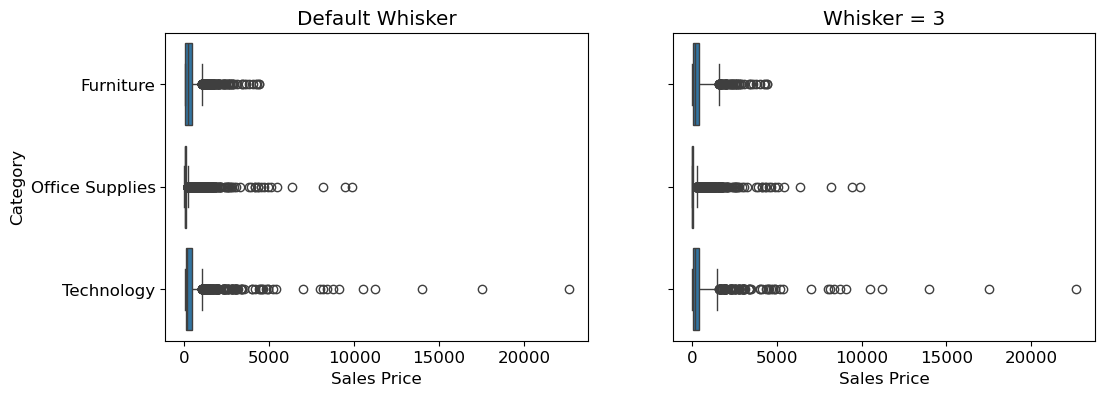

In [151]:
fig, axs = plt.subplots(1,2, sharey=True, figsize=(12,4))
sns.boxplot(data=data, x = 'Sales Price', y='Category', ax=axs[0])
sns.boxplot(data=data, x =  'Sales Price', y='Category', whis=3, ax=axs[1])
axs[0].set_title("Default Whisker")
axs[1].set_title("Whisker = 3")
plt.show()

In [154]:
def count_outliers(s, whis=1.5):
    q1,q3 = np.percentile(s, [25,75])
    iqr = q3 - q1
    low, up = q1 - (iqr*whis), q3 + (iqr*whis)
    count = len(s.loc[(s < low) | (s > up)])
    return count

print(count_outliers(data['Sales Price']))
print(count_outliers(data['Sales Price'],whis = 3))

1167
668


In [168]:
def remove_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    print(f"Q1: {q1:2f}\nQ3:  {q3:2f}\n IQR:  {iqr:.2f}\nLower Bound: {lower_bound:.2f}\nUpper Bound: {upper_bound:.2f}\nNumber of outliers in column: 'Sales Price' is {count_outliers(data['Sales Price'],whis = 3)} ")

    return df[-outlier_mask]

print(remove_outliers(data, 'Sales Price').shape)
remove_outliers(data, 'Profit').shape

Q1: 17.280000
Q3:  209.940000
 IQR:  192.66
Lower Bound: -560.70
Upper Bound: 787.92
Number of outliers in column: 'Sales Price' is 668 
(9325, 29)
Q1: 1.731000
Q3:  29.364000
 IQR:  27.63
Lower Bound: -81.17
Upper Bound: 112.26
Number of outliers in column: 'Sales Price' is 668 


(8825, 29)

In [170]:
def remove_outlier(data, col, whis=1.5):
    q1,q3 = np.percentile(data[col], [25,75])
    iqr = q3 - q1
    low, up = q1 - (iqr*whis), q3 + (iqr*whis)
    data_new = data.loc[(data[col]  >= low) & (data[col] <= up)]
    return data_new
print(remove_outlier(data, 'Sales Price').shape)

(8826, 29)


Q1: 17.280000
Q3:  209.940000
 IQR:  192.66
Lower Bound: -560.70
Upper Bound: 787.92
Number of outliers in column: 'Sales Price' is 668 
Shape at dataframe after removing the outliers in 'Sales Price' column - (9325, 29)


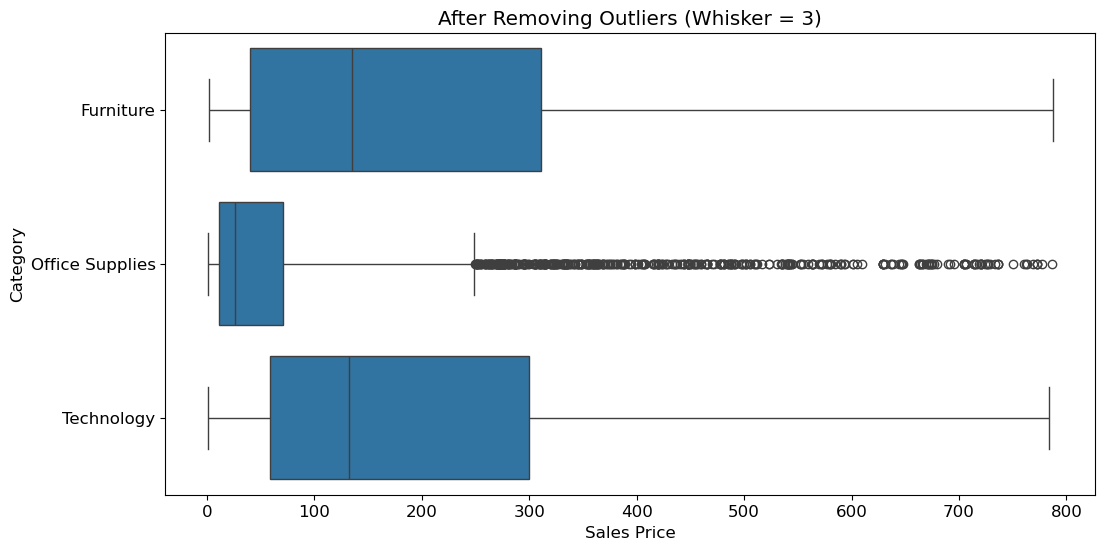

In [173]:
data = remove_outliers(data, 'Sales Price')
print(f"Shape at dataframe after removing the outliers in 'Sales Price' column - {data.shape}")
sns.boxplot(data = data, x = 'Sales Price', y = 'Category', whis = 3)
plt.title("After Removing Outliers (Whisker = 3)")
plt.show()

**Profit column**
 *  most of the outliers will be gone due to removal of outliers in Sales Price column

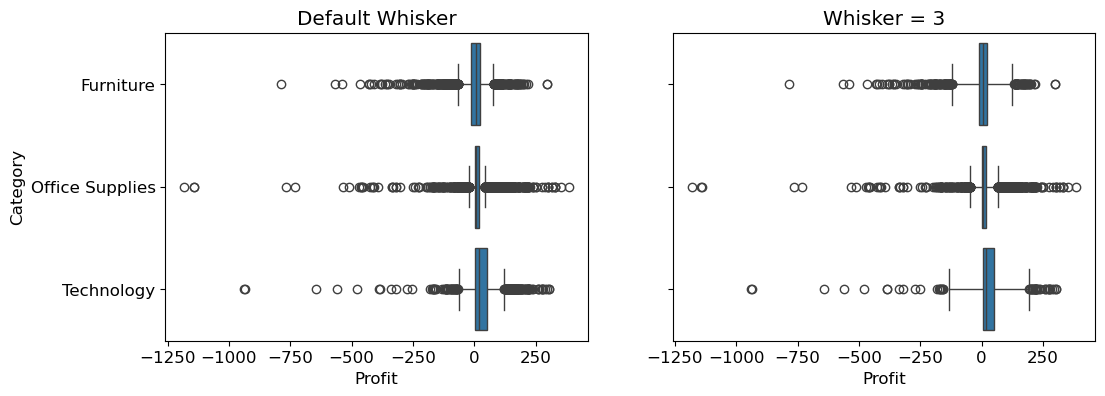

In [174]:
fig, axs = plt.subplots(1,2, sharey=True, figsize = (12,4))
sns.boxplot(data=data, x='Profit' , y='Category', ax=axs[0])
sns.boxplot(data=data, x='Profit' , y= 'Category', whis=3, ax=axs[1])
axs[0].set_title("Default Whisker")
axs[1].set_title("Whisker = 3")
plt.show()

Q1: 1.670400
Q3:  23.756400
 IQR:  22.09
Lower Bound: -64.59
Upper Bound: 90.01
Number of outliers in column: 'Sales Price' is 307 
Shape of dataframe after removing the outliers in 'Profit' column - (8455, 29)


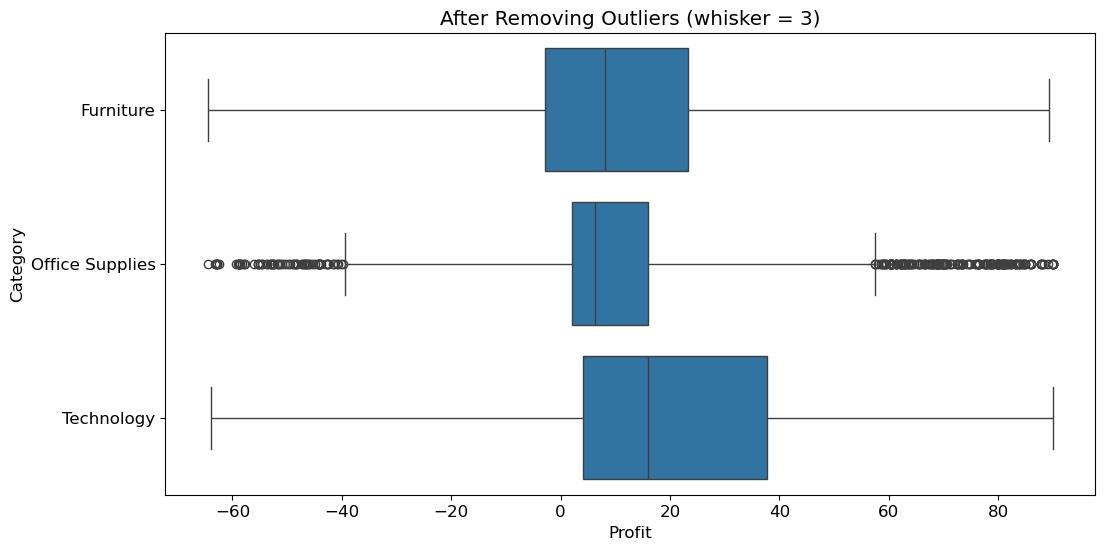

In [176]:
data = remove_outliers(data, 'Profit')
print(f"Shape of dataframe after removing the outliers in 'Profit' column - {data.shape}")
sns.boxplot(data=data, x='Profit', y='Category', whis=3)
plt.title("After Removing Outliers (whisker = 3)")
plt.show()

In [177]:
data.reset_index(drop=True, inplace = True)

**Outlier Detection and Handling: Summary**

* **Action Taken:** A reusable function was created to detect and remove outliers from a specified column using the 3 * IQR rule, as required by the case study. This method was chosen to be more conservative, removing only the most extreme values from a dataset with high variance like sales data.
* **Application & Impact:**
* **1. On Sales Price:**
    * The function identified an upper bound of **$788.02**.
    * **668 rows** with a `Sales Price` above this bound were flagged as outliers and removed.


* **2. On Profit:**
    * The function was then applied to the already-filtered data. It identified bounds of **-$64.47** and **$89.86**.
    * An additional **882 rows** with `Profit` outside this range were removed.




* **Overall Impact of Cleaning:**
    * **Total Rows Removed:** 1,550 (9997 - 8447).
    * **Unique Order IDs Affected:** 395 (5009 - 4614).


* **Outcome:** The dataset has been trimmed of its most extreme financial outliers. The main `data` DataFrame has been updated to this cleaned version.

In [179]:
print("Original columns from cleaning phase:", data.columns.tolist())

Original columns from cleaning phase: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales Price', 'Quantity', 'Discount', 'Profit', 'days_to_ship', 'customer_name_masked', 'original_prices', 'total_sales', 'tota_profit', 'original_price', 'discount_price', 'total_discount', 'Shipping_urgency', 'days_since_last_order']
